In [1]:
!pip install pandas numpy matplotlib seaborn plotly openpyxl

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.rcParams["figure.figsize"]=(10,6)

In [6]:
from google.colab import files

uploaded = files.upload()

Saving Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv to Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


In [8]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

In [9]:
df.head()
df.tail()
df.sample(5)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
5218,TXN05219,U05219,32,Other,8.56,2.89,3.52,5.85,5.59,213,65,11.54,High,No,Severe,1
1848,TXN01849,U01849,28,Other,9.25,5.93,1.87,0.80,7.75,51,161,12.08,Low,No,Severe,1
3485,TXN03486,U03486,24,Male,8.60,4.70,1.45,2.53,8.89,60,67,10.28,Low,Yes,Severe,1
4232,TXN04233,U04233,35,Female,6.20,1.93,1.05,1.20,5.24,229,74,8.27,Medium,Yes,Mild,0
4868,TXN04869,U04869,19,Other,5.34,2.56,2.78,3.30,6.30,240,100,7.39,Low,Yes,NaN,0


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7500
Columns: 16


In [11]:
print(df.columns.tolist())

['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [13]:
df.dtypes

,0
transaction_id,object
user_id,object
age,int64
gender,object
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,int64


In [14]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [15]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [16]:
missing_percent = (
    df.isnull().sum()
    / len(df)
) * 100

missing_percent.sort_values(ascending=False)

,0
addiction_level,10.92
transaction_id,0.00
age,0.00
user_id,0.00
daily_screen_time_hours,0.00
social_media_hours,0.00
gaming_hours,0.00
gender,0.00
work_study_hours,0.00
sleep_hours,0.00


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*50)

transaction_id
7500
--------------------------------------------------
user_id
7500
--------------------------------------------------
age
18
--------------------------------------------------
gender
3
--------------------------------------------------
daily_screen_time_hours
900
--------------------------------------------------
social_media_hours
551
--------------------------------------------------
gaming_hours
401
--------------------------------------------------
work_study_hours
551
--------------------------------------------------
sleep_hours
451
--------------------------------------------------
notifications_per_day
231
--------------------------------------------------
app_opens_per_day
166
--------------------------------------------------
weekend_screen_time
1096
--------------------------------------------------
stress_level
3
--------------------------------------------------
academic_work_impact
2
--------------------------------------------------
addiction_level
3
---

In [26]:
print(len(df.columns))
print(df.columns.tolist())

16
['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


In [27]:
feature_dictionary = pd.DataFrame({
    "Feature": df.columns
})

feature_dictionary["Category"] = [
    "Identifier",      # transaction_id
    "Identifier",      # user_id
    "Demographic",     # age
    "Demographic",     # gender
    "Usage",           # daily_screen_time_hours
    "Usage",           # social_media_hours
    "Usage",           # gaming_hours
    "Productivity",    # work_study_hours
    "Wellbeing",       # sleep_hours
    "Dependency",      # notifications_per_day
    "Dependency",      # app_opens_per_day
    "Usage",           # weekend_screen_time
    "Psychology",      # stress_level
    "Performance",     # academic_work_impact
    "Addiction",       # addiction_level
    "Target"           # addicted_label
]

feature_dictionary

,Feature,Category
0,transaction_id,Identifier
1,user_id,Identifier
2,age,Demographic
3,gender,Demographic
4,daily_screen_time_hours,Usage
5,social_media_hours,Usage
6,gaming_hours,Usage
7,work_study_hours,Productivity
8,sleep_hours,Wellbeing
9,notifications_per_day,Dependency


In [28]:
feature_dictionary.to_csv(
    "feature_dictionary.csv",
    index=False
)

In [29]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')

In [30]:
categorical_cols = df.select_dtypes(
    exclude=np.number
).columns

categorical_cols

Index(['transaction_id', 'user_id', 'gender', 'stress_level',
       'academic_work_impact', 'addiction_level'],
      dtype='object')

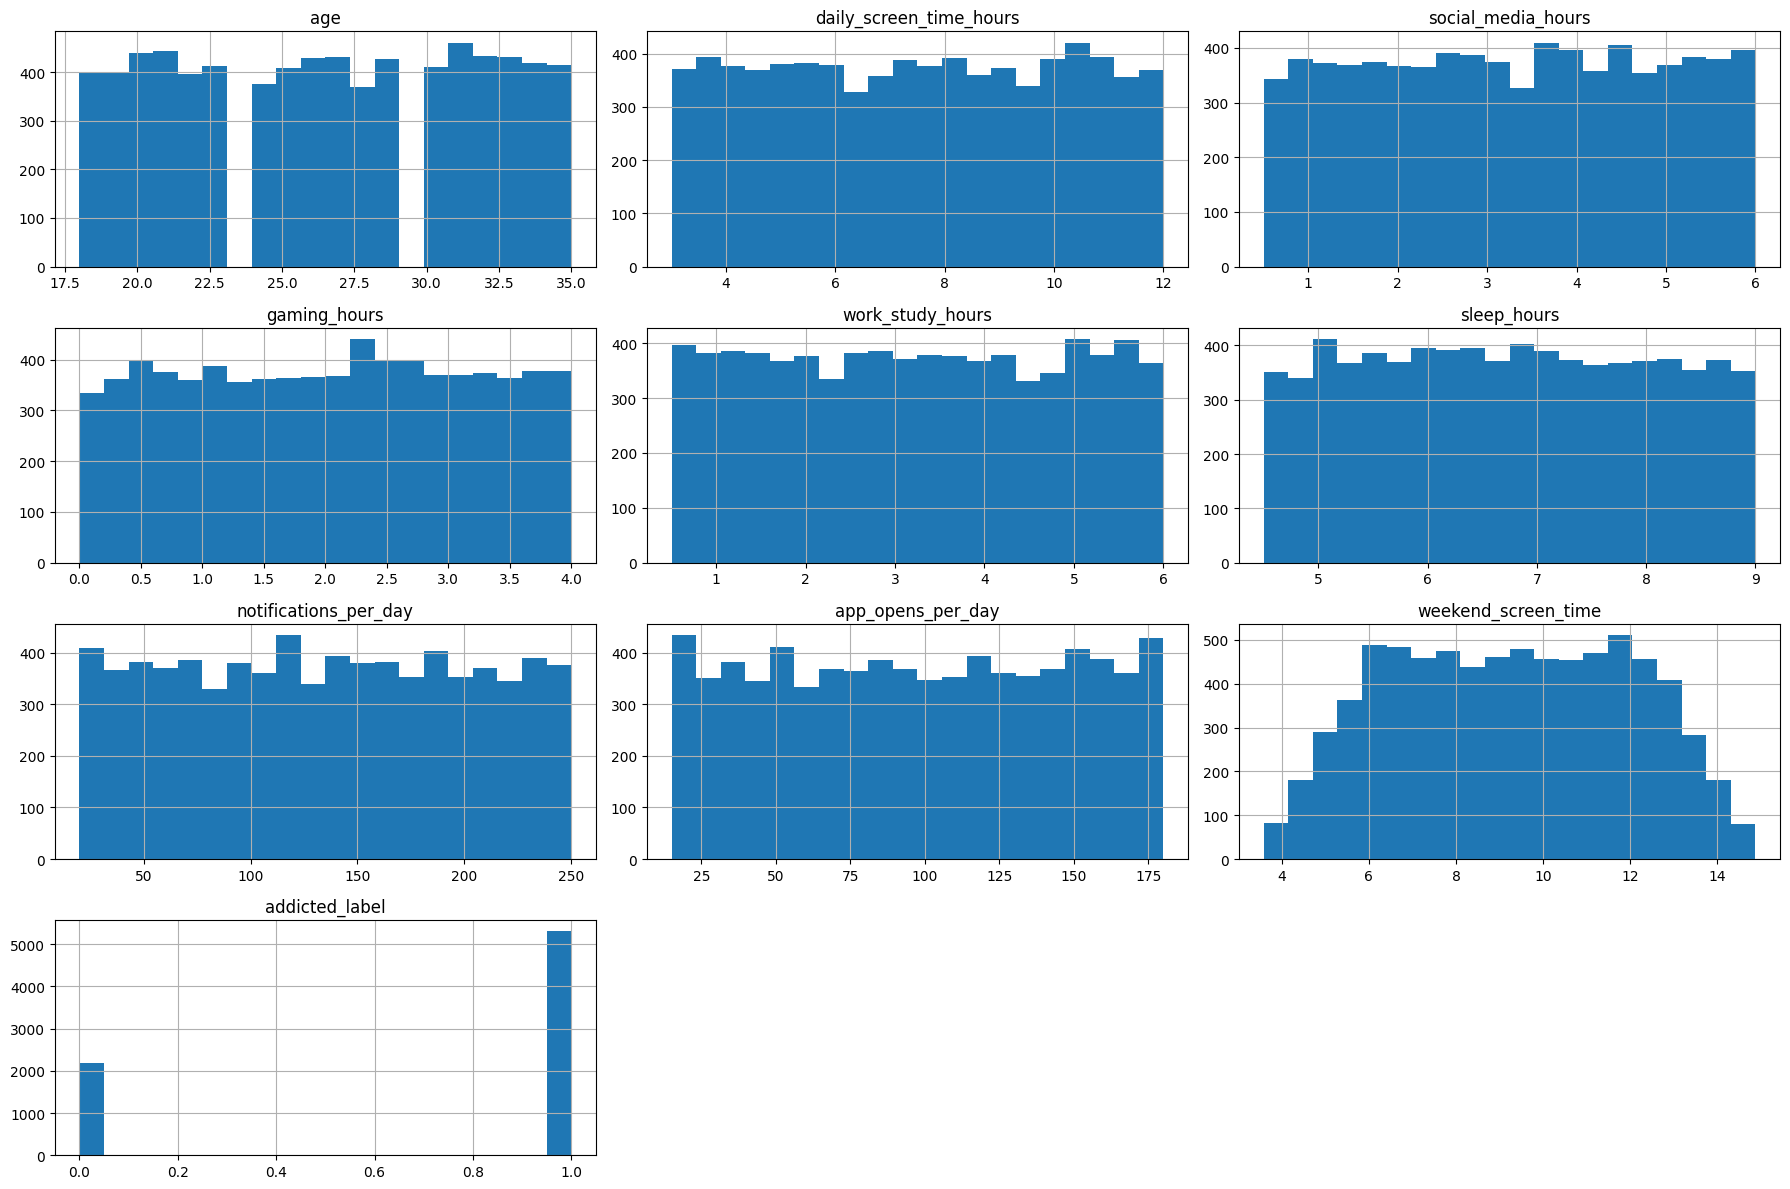

In [31]:
df[numeric_cols].hist(
    figsize=(18,12),
    bins=20
)

plt.tight_layout()
plt.show()

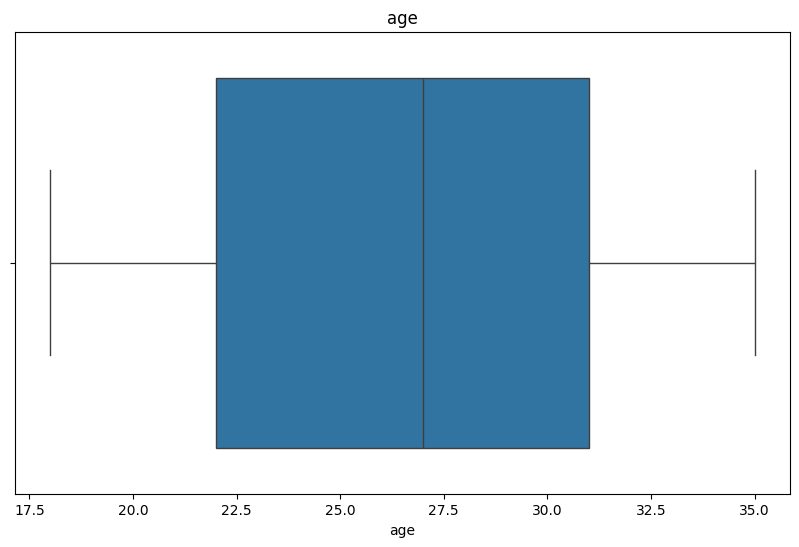

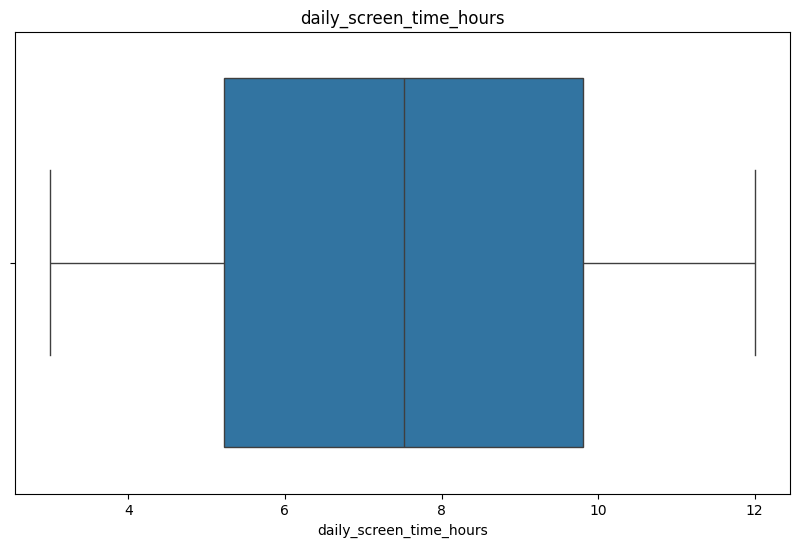

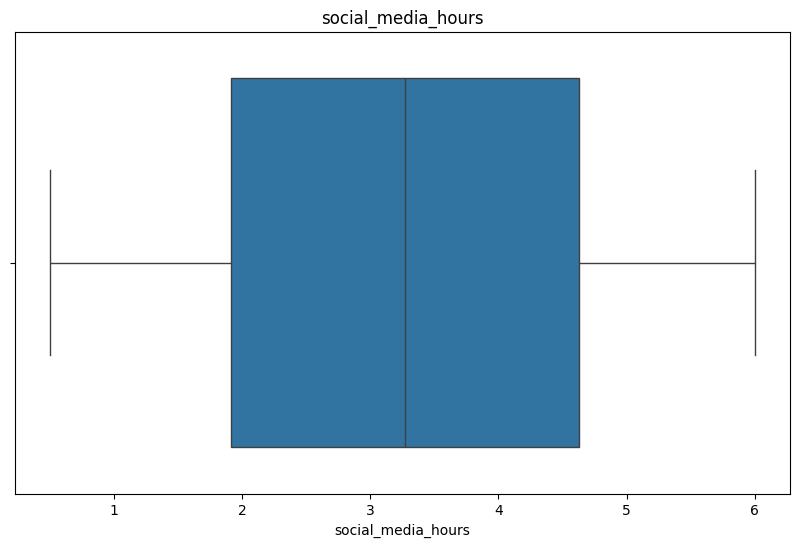

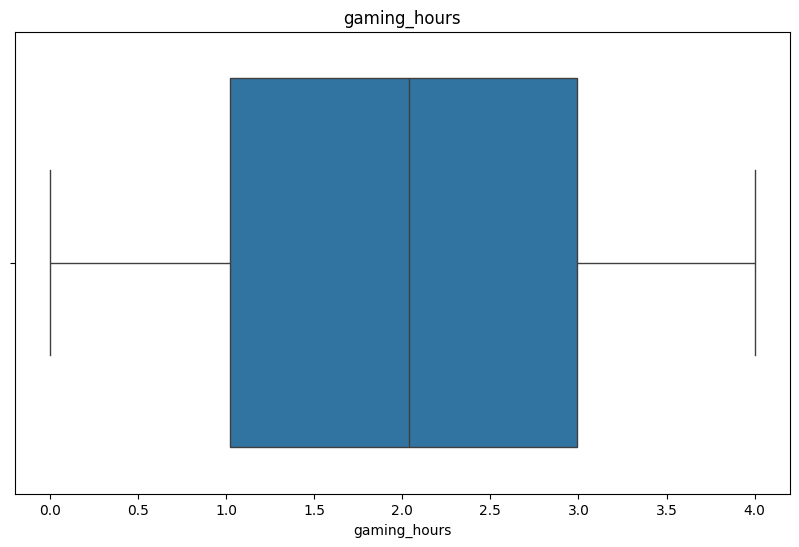

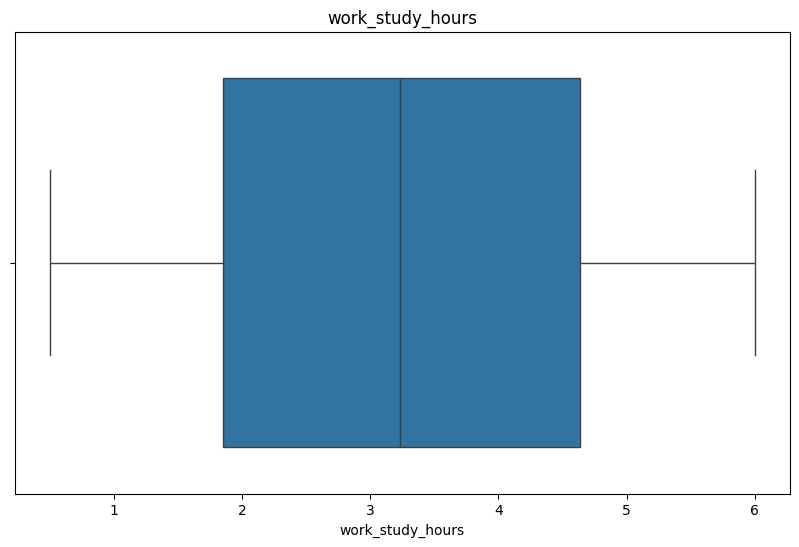

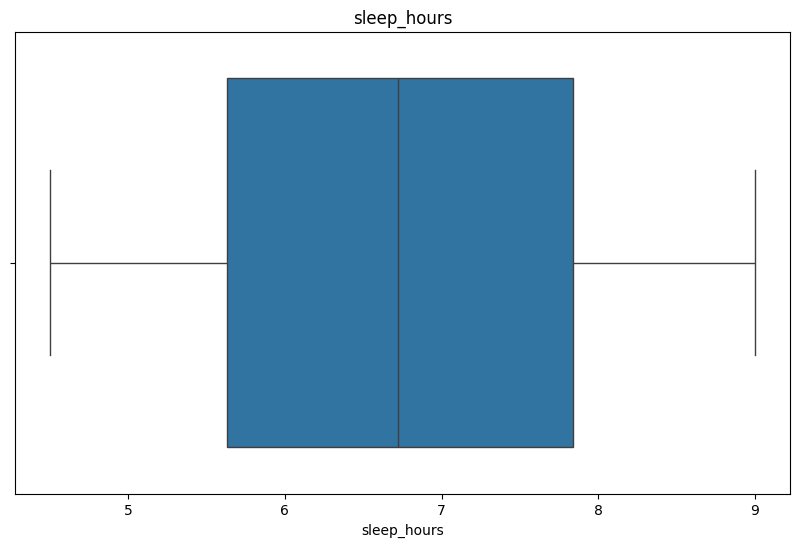

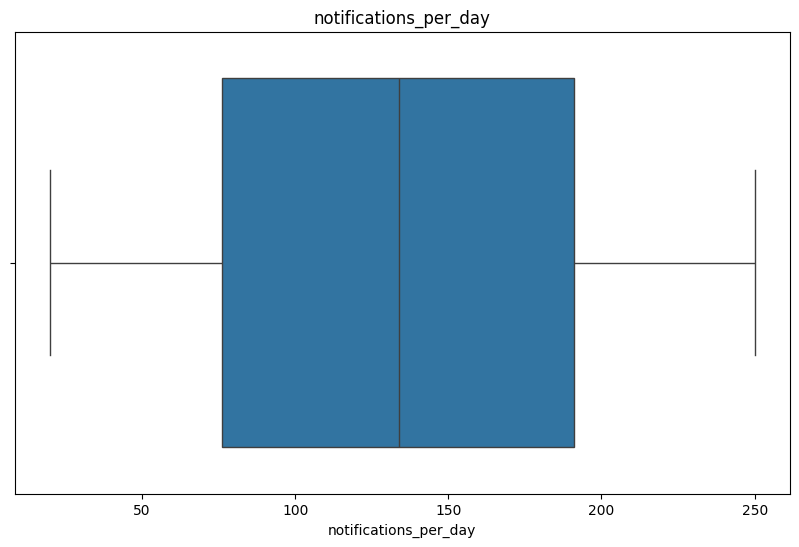

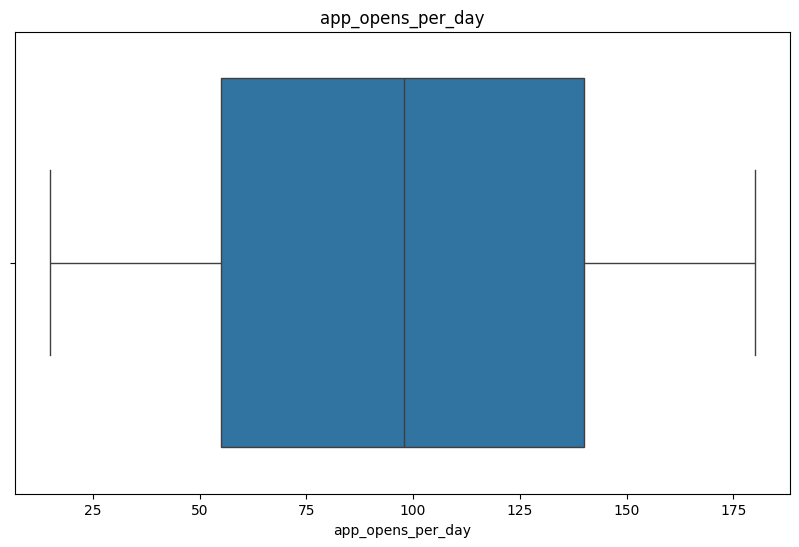

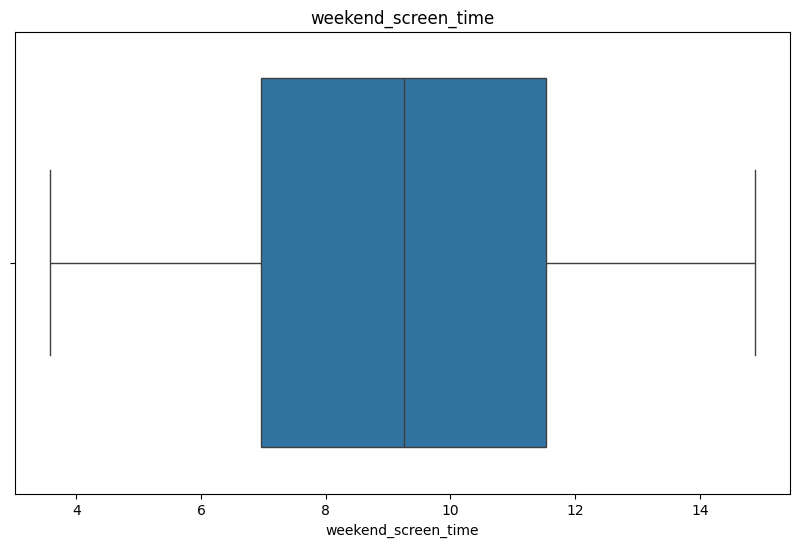

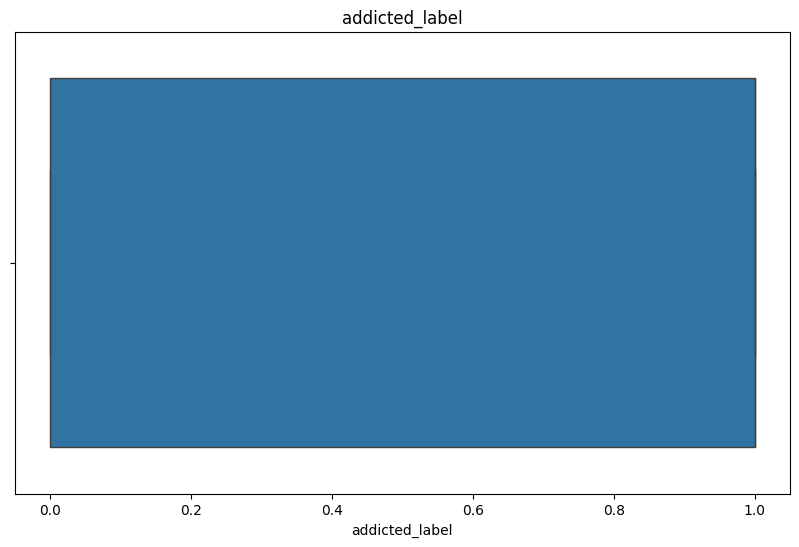

In [32]:
for col in numeric_cols:

    plt.figure()

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [33]:
corr = df[numeric_cols].corr()

corr

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
age,1.000000,0.012767,0.000342,-0.026107,-0.017147,-0.007462,0.000387,-0.002276,0.015286,0.004220
daily_screen_time_hours,0.012767,1.000000,0.010321,0.001140,0.003108,0.019343,0.000811,0.024448,0.964295,0.577112
social_media_hours,0.000342,0.010321,1.000000,-0.000902,-0.002580,0.005947,-0.008593,-0.000371,0.011404,0.414244
gaming_hours,-0.026107,0.001140,-0.000902,1.000000,0.004384,-0.002874,0.015563,-0.009917,-0.006282,0.008485
work_study_hours,-0.017147,0.003108,-0.002580,0.004384,1.000000,-0.027150,-0.017518,-0.021676,0.004667,0.001103
sleep_hours,-0.007462,0.019343,0.005947,-0.002874,-0.027150,1.000000,0.016273,0.005692,0.018933,0.035496
notifications_per_day,0.000387,0.000811,-0.008593,0.015563,-0.017518,0.016273,1.000000,0.004598,-0.002199,-0.000660
app_opens_per_day,-0.002276,0.024448,-0.000371,-0.009917,-0.021676,0.005692,0.004598,1.000000,0.021069,0.011041
weekend_screen_time,0.015286,0.964295,0.011404,-0.006282,0.004667,0.018933,-0.002199,0.021069,1.000000,0.555426
addicted_label,0.004220,0.577112,0.414244,0.008485,0.001103,0.035496,-0.000660,0.011041,0.555426,1.000000


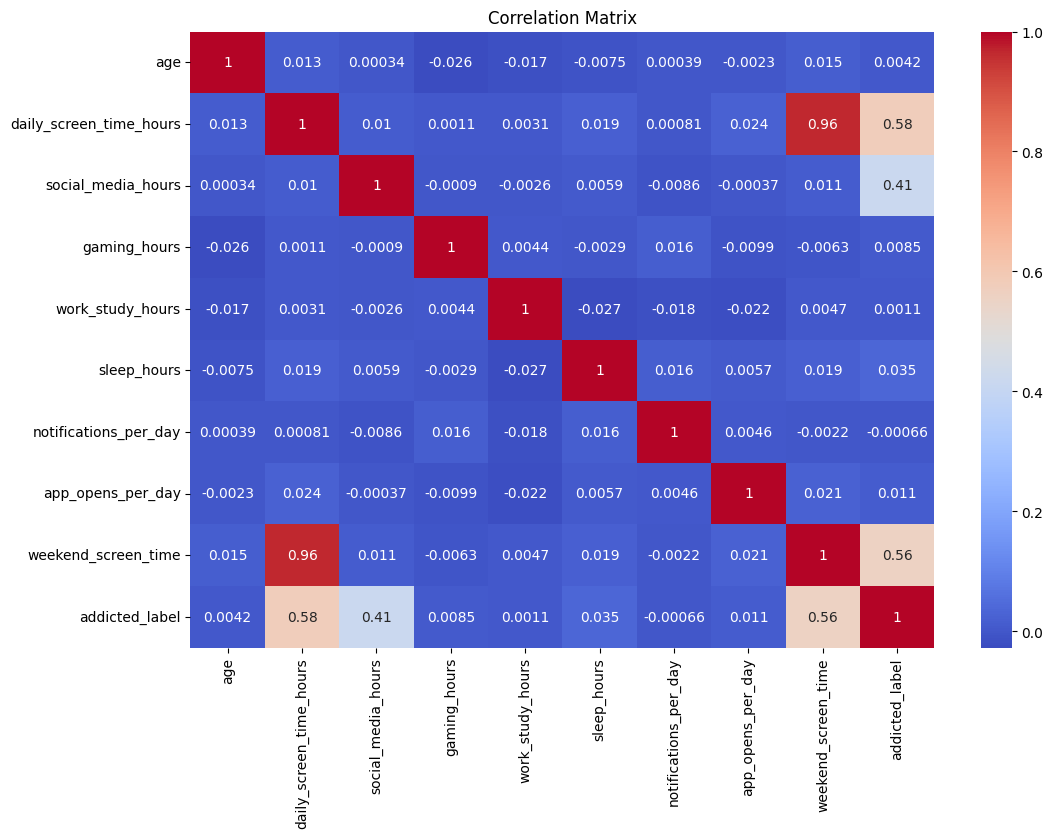

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [35]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    ascending=False
)

corr_pairs.head(20)

,,0
age,age,1.000000
gaming_hours,gaming_hours,1.000000
social_media_hours,social_media_hours,1.000000
daily_screen_time_hours,daily_screen_time_hours,1.000000
app_opens_per_day,app_opens_per_day,1.000000
notifications_per_day,notifications_per_day,1.000000
addicted_label,addicted_label,1.000000
weekend_screen_time,weekend_screen_time,1.000000
sleep_hours,sleep_hours,1.000000
work_study_hours,work_study_hours,1.000000


['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


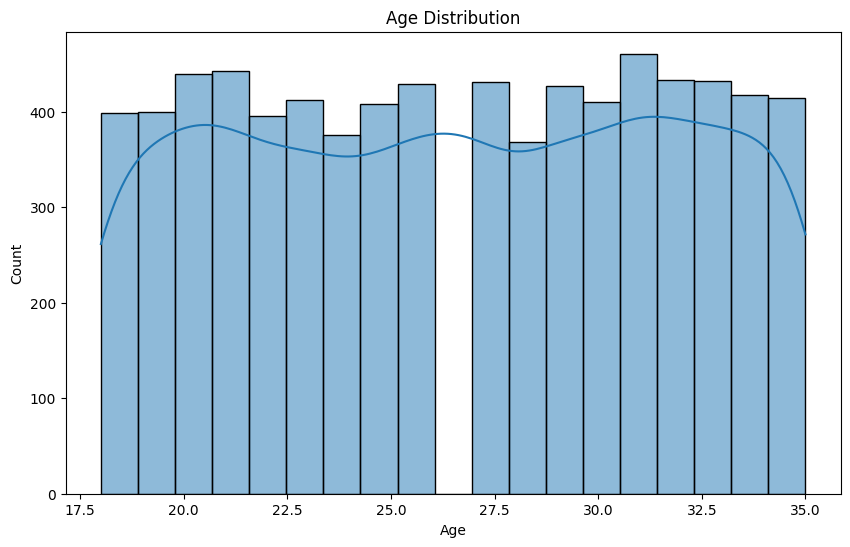

In [37]:
# Check available columns first
print(df.columns.tolist())

# Plot Age Distribution
sns.histplot(
    data=df,
    x='age',
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

['Male' 'Other' 'Female']


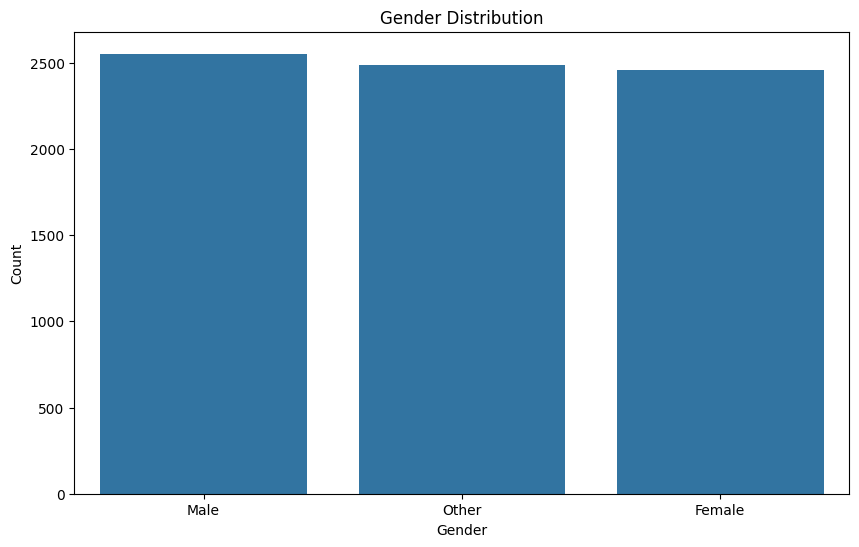

In [40]:
# Check unique values first
print(df['gender'].unique())

# Gender Distribution
sns.countplot(
    data=df,
    x='gender'
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


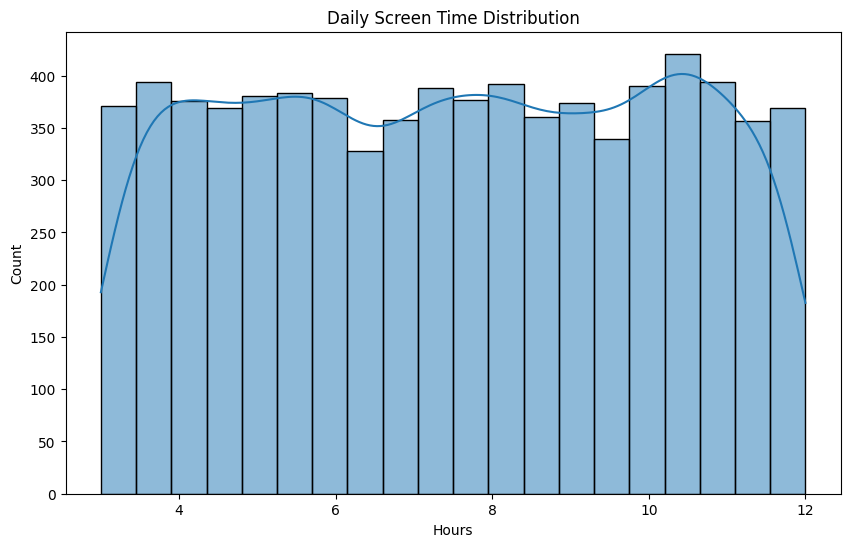

In [42]:
# Verify column exists
print(df.columns.tolist())

# Screen Time Distribution
sns.histplot(
    data=df,
    x='daily_screen_time_hours',
    kde=True
)

plt.title("Daily Screen Time Distribution")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

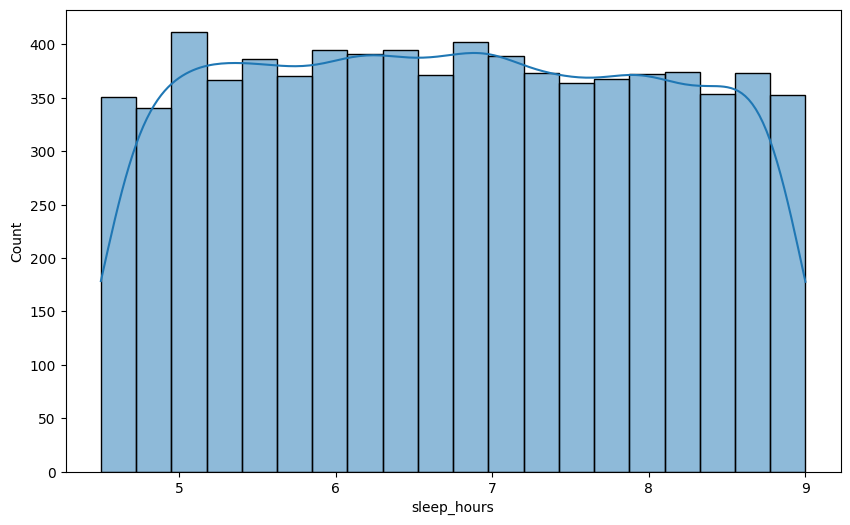

In [44]:
sns.histplot(
    df['sleep_hours'],
    kde=True
)

plt.show()

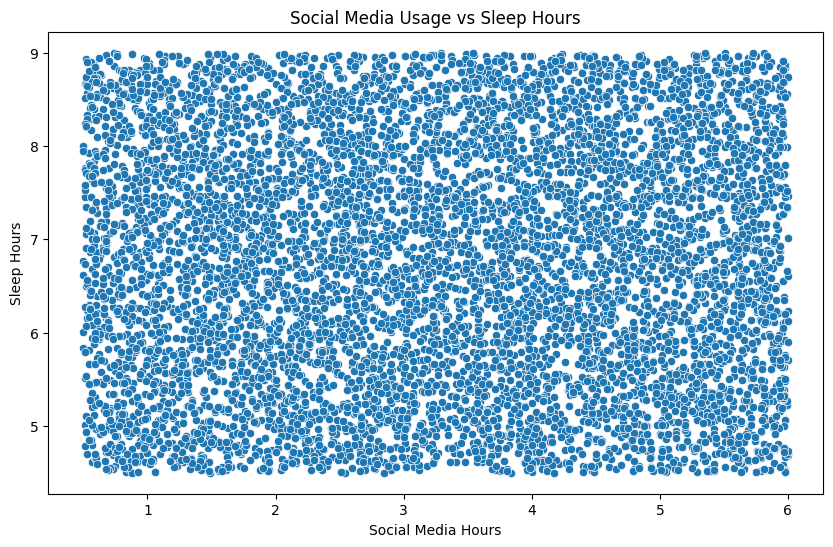

In [46]:
# Social Media Usage vs Sleep Hours

sns.scatterplot(
    data=df,
    x='social_media_hours',
    y='sleep_hours'
)

plt.title("Social Media Usage vs Sleep Hours")
plt.xlabel("Social Media Hours")
plt.ylabel("Sleep Hours")
plt.show()

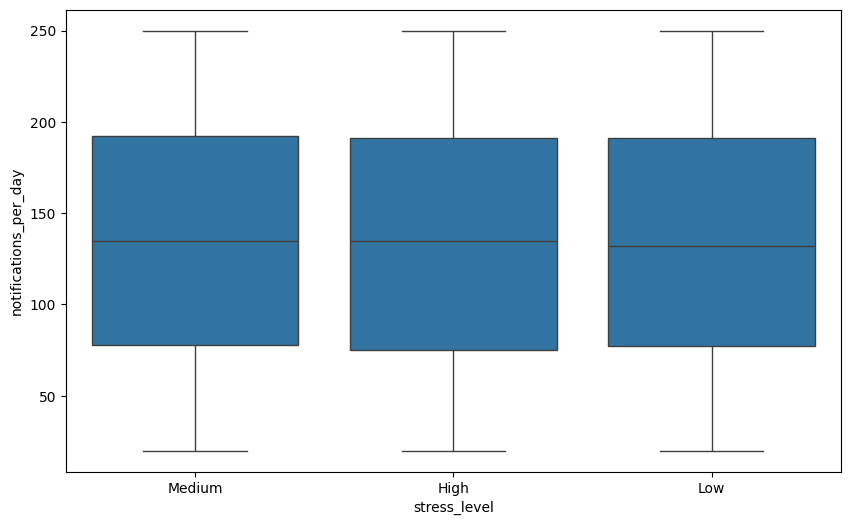

In [47]:
sns.boxplot(
    data=df,
    x='stress_level',
    y='notifications_per_day'
)

plt.show()

In [48]:
summary = pd.DataFrame({

    "Column": df.columns,

    "Missing_Values":
        df.isnull().sum().values,

    "Unique_Values":
        df.nunique().values,

    "Data_Type":
        df.dtypes.values

})

In [49]:
summary.to_csv(
    "dataset_summary.csv",
    index=False
)

1. Average screen time is X hours.

2. Users receiving more notifications
appear to have higher stress.

3. Social media usage negatively
correlates with sleep duration.

4. App opens strongly correlate with
addiction levels.

5. Screen time appears to increase
with addiction score.

####Outputs Generated From Notebook 1
feature_dictionary.csv

dataset_summary.csv

correlation_heatmap.png

EDA_visuals/

research_notes.md